# Práctica: Preparación y Limpieza de Datos
## Definición del Problema

* **Dataset Seleccionado:** Default of Credit Card Clients (UCI Machine Learning Repository). Contiene información demográfica, historial de pagos y facturación de clientes de tarjetas de crédito en Taiwán.
* **Algoritmo a utilizar:** Regresión Logística (Problema de Clasificación Supervisada).
* **Variable Objetivo:** `default.payment.next.month` (Binaria: 1 = Incurre en impago el próximo mes, 0 = No incurre en impago).
* **Métrica de Evaluación:** Aunque mediremos la *Accuracy* (Exactitud) como métrica base, prestaremos especial atención a métricas como *Recall* o el *F1-Score*. 
    * *Justificación de Negocio:* En detección de fraude o riesgo de crédito, los datasets suelen estar desbalanceados (hay muchos menos morosos que clientes al día). Si el modelo predice que "nadie impaga", la *Accuracy* será alta, pero el modelo será inútil para el banco. Nos interesa minimizar los Falsos Negativos (clientes que impagan pero que el modelo clasificó como buenos).
* **Objetivo de Negocio:** Reducir el riesgo crediticio (NPL - Non-Performing Loans). Al identificar proactivamente qué clientes tienen alta probabilidad de impagar su tarjeta de crédito el próximo mes, el banco (ej. BBVA) puede activar protocolos de contención: reducir límites de crédito, ofrecer refinanciación o lanzar campañas de educación financiera preventiva, protegiendo así el balance del banco.

### Importing Libraries

In [19]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# Ignoramos warnings temporales para mantener el notebook limpio para la presentación
warnings.filterwarnings('ignore') 

### Read the Data
- Describe each column
- rename the columns' names for easy use.

In [3]:
### Read the Data
# 1. Cargamos los datos omitiendo la primera fila de metadatos (header=1), ya que La primera fila (índice 0) contiene nombres genéricos (X1, X2, Y)
file_path = 'data/default_of_credit_card_clients.xls'
df = pd.read_excel(file_path, header=1)

In [4]:
# 2. Estandarizamos los nombres de las columnas a 'snake_case'
df.columns = [col.lower().replace(' ', '_').replace('.', '_') for col in df.columns]

# 3. Renombramos la variable objetivo a algo más corto y claro para el negocio
df.rename(columns={'default_payment_next_month': 'default_payment'}, inplace=True)

# 4. Revisamos que la carga fue exitosa
print(f"Dimensiones iniciales del dataset: {df.shape}")
display(df.head())

Dimensiones iniciales del dataset: (30000, 25)


,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Understanding and Examinate Data
### Check the head, shape, data-types of the features
- Fixing a data type

In [5]:
# 1. Revisión de tipos de datos y valores no nulos
print("--- Información general del Dataset ---")
df.info()
print("\n")

--- Información general del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               30000 non-null  int64
 1   limit_bal        30000 non-null  int64
 2   sex              30000 non-null  int64
 3   education        30000 non-null  int64
 4   marriage         30000 non-null  int64
 5   age              30000 non-null  int64
 6   pay_0            30000 non-null  int64
 7   pay_2            30000 non-null  int64
 8   pay_3            30000 non-null  int64
 9   pay_4            30000 non-null  int64
 10  pay_5            30000 non-null  int64
 11  pay_6            30000 non-null  int64
 12  bill_amt1        30000 non-null  int64
 13  bill_amt2        30000 non-null  int64
 14  bill_amt3        30000 non-null  int64
 15  bill_amt4        30000 non-null  int64
 16  bill_amt5        30000 non-null  int64
 17  bill_amt6        3000

___

### Check the statistical values of features

In [6]:
# 2. Estadísticas descriptivas (para detectar anomalías a simple vista)
# Transponemos (.T) para que sea más fácil de leer en la pantalla
print("--- Estadísticas Descriptivas ---")
display(df.describe().T)

--- Estadísticas Descriptivas ---


,count,mean,std,min,25%,50%,75%,max
id,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
limit_bal,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
sex,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
education,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
marriage,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
age,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
pay_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
pay_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
pay_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
pay_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


___

### Identifique las filas que contienen datos duplicados
  - Eliminar filas que contienen datos duplicados

In [7]:
# 3. ¿Tenemos filas duplicadas exactas?
duplicados = df.duplicated().sum()
print(f"\nNúmero de filas exactamente duplicadas: {duplicados}")


Número de filas exactamente duplicadas: 0


### Drop the attributes that provide no useful information

In [8]:
# 4. Eliminamos el 'id' ya que no aporta valor predictivo para el negocio
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)
    print("Columna 'id' eliminada con éxito.\n")

Columna 'id' eliminada con éxito.



### Identifique las columnas que contienen un valor único
- Elimine las columnas que contengan un solo valor
### Considere las columnas que tienen muy pocos valores
  - Quite las columnas que tengan una varianza baja

In [9]:
# 5. Eliminar columnas de valor único o baja varianza
# Utilizamos un umbral conservador (1e-6), razón: -> Mantener variables que no cambian es un desperdicio de memoria y coste de procesamiento
varianzas = df.select_dtypes(include=[np.number]).var()
columnas_baja_varianza = varianzas[varianzas < 1e-6].index.tolist()
print(f"Columnas eliminadas por baja varianza: {columnas_baja_varianza}")
if columnas_baja_varianza:
    df.drop(columns=columnas_baja_varianza, inplace=True)

Columnas eliminadas por baja varianza: []


___

### check the missing values
- fill missing values

De acuerdo con nuestro Diccionario de Datos:

- **education** debería ser 1, 2, 3 o 4. (Pero si miras tu tabla, el mínimo es 0 y el máximo es 6).

- **marriage** (Estado civil) debería ser 1, 2 o 3. (Pero el mínimo es 0).

In [10]:
# 6. Detectar y limpiar valores extraños (fuera de diccionario)
print("--- Valores únicos ANTES de la limpieza ---")
print(f"Educación: {sorted(df['education'].unique())}")
print(f"Estado Civil: {sorted(df['marriage'].unique())}")

--- Valores únicos ANTES de la limpieza ---
Educación: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Estado Civil: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [11]:
# Reemplazamos lo que NO esté en la lista permitida por la categoría "Otros"
# Para education "Otros" es 4. Para marriage "Otros" es 3.
df['education'] = df['education'].where(df['education'].isin([1, 2, 3, 4]), 4)
df['marriage']  = df['marriage'].where(df['marriage'].isin([1, 2, 3]), 3)

print("\n--- Valores únicos DESPUÉS de la limpieza ---")
print(f"Educación: {sorted(df['education'].unique())}")
print(f"Estado Civil: {sorted(df['marriage'].unique())}")


--- Valores únicos DESPUÉS de la limpieza ---
Educación: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Estado Civil: [np.int64(1), np.int64(2), np.int64(3)]


In [12]:
# Breve chequeo a la historia de pagos (pay_0 a pay_6)
# El diccionario dice -1 (pago a tiempo), 1, 2, 3... (meses de retraso).
# Veremos valores -2 y 0. En este dataset de Taiwán:
# -2 = Sin consumo, -1 = Pago total, 0 = Pago mínimo (crédito revolving).
# No los consideraremos errores, son datos válidos del comportamiento del cliente.

### Detect strange values apart from the NaN Values
- Clear strange values apart from the NaN Values

> Enfoque de Negocio:
Si entra un NaN a un algoritmo como Regresión Logística, directamente dará un error y fallará. ¿Qué hacemos cuando un cliente tiene un campo vacío (por ejemplo, edad o ingresos)?

- ¿Borrar la fila? Solo si los nulos son poquísimos (ej. 0.1% de los datos). Si borramos mucho, perdemos historiales de clientes valiosos.

- ¿Borrar la columna? Solo si tiene más de un 40-50% de nulos y no aporta valor.

- ¿Imputar (Rellenar)? Es lo ideal. Si falta un valor monetario, solemos rellenar con la mediana (porque no le afectan los valores extremos). Si falta una categoría, usamos la moda (el valor más frecuente) o creamos una categoría nueva llamada "Desconocido" (a veces, que el cliente se niegue a dar un dato es, en sí mismo, un factor de riesgo).

In [13]:
# 7. Revisión y llenado de valores faltantes (NaNs)
print("--- Chequeo de Missing Values (NaNs) ---")

# Calculamos la cantidad y el porcentaje de nulos por columna
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100)

# Creamos un DataFrame resumen para verlo mejor
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values(by="missing_count", ascending=False)
# Filtramos solo las columnas que tengan al menos 1 nulo
columnas_con_nulos = missing_summary[missing_summary["missing_count"] > 0]

if columnas_con_nulos.empty:
    print("¡Excelente noticia! No tenemos valores nulos (NaNs) en el dataset.")
else:
    print("Columnas con valores nulos encontradas:")
    display(columnas_con_nulos)

--- Chequeo de Missing Values (NaNs) ---
¡Excelente noticia! No tenemos valores nulos (NaNs) en el dataset.


___

### Check outliers
    - Tienen un impacto significativo en modelos que usan distancias

**Visión de Negocio:**

- **El Problema Técnico:** En Regresión Lineal o Logística. Estos algoritmos calculan "distancias" y pesos (coeficientes) para cada variable. Si el 99% de nuestros clientes tiene un límite de crédito entre 10,000 y 200,000, pero tenemos un cliente VIP con un límite de 1,000,000, ese único cliente va a "tirar" de la línea de regresión hacia él, distorsionando el modelo para la mayoría normal.

- **La Solución de Negocio:** ¿Borramos al cliente VIP? ¡Jamás! Es un cliente real y queremos predecir si va a impagar. Lo que se hace en la banca es una técnica llamada **Winsorization (o Capping / Topeo)**. Consiste en coger a los extremos y "toparlos" a un percentil alto (ej. 99%). Es decir, a efectos del modelo, al cliente de 1,000,000 le diremos que tiene 500,000 (el percentil 99). Mantenemos la fila, mantenemos la información de que "es mucho dinero", pero evitamos que rompa las matemáticas del algoritmo.

--- Visualización de Outliers con Box Plots ---


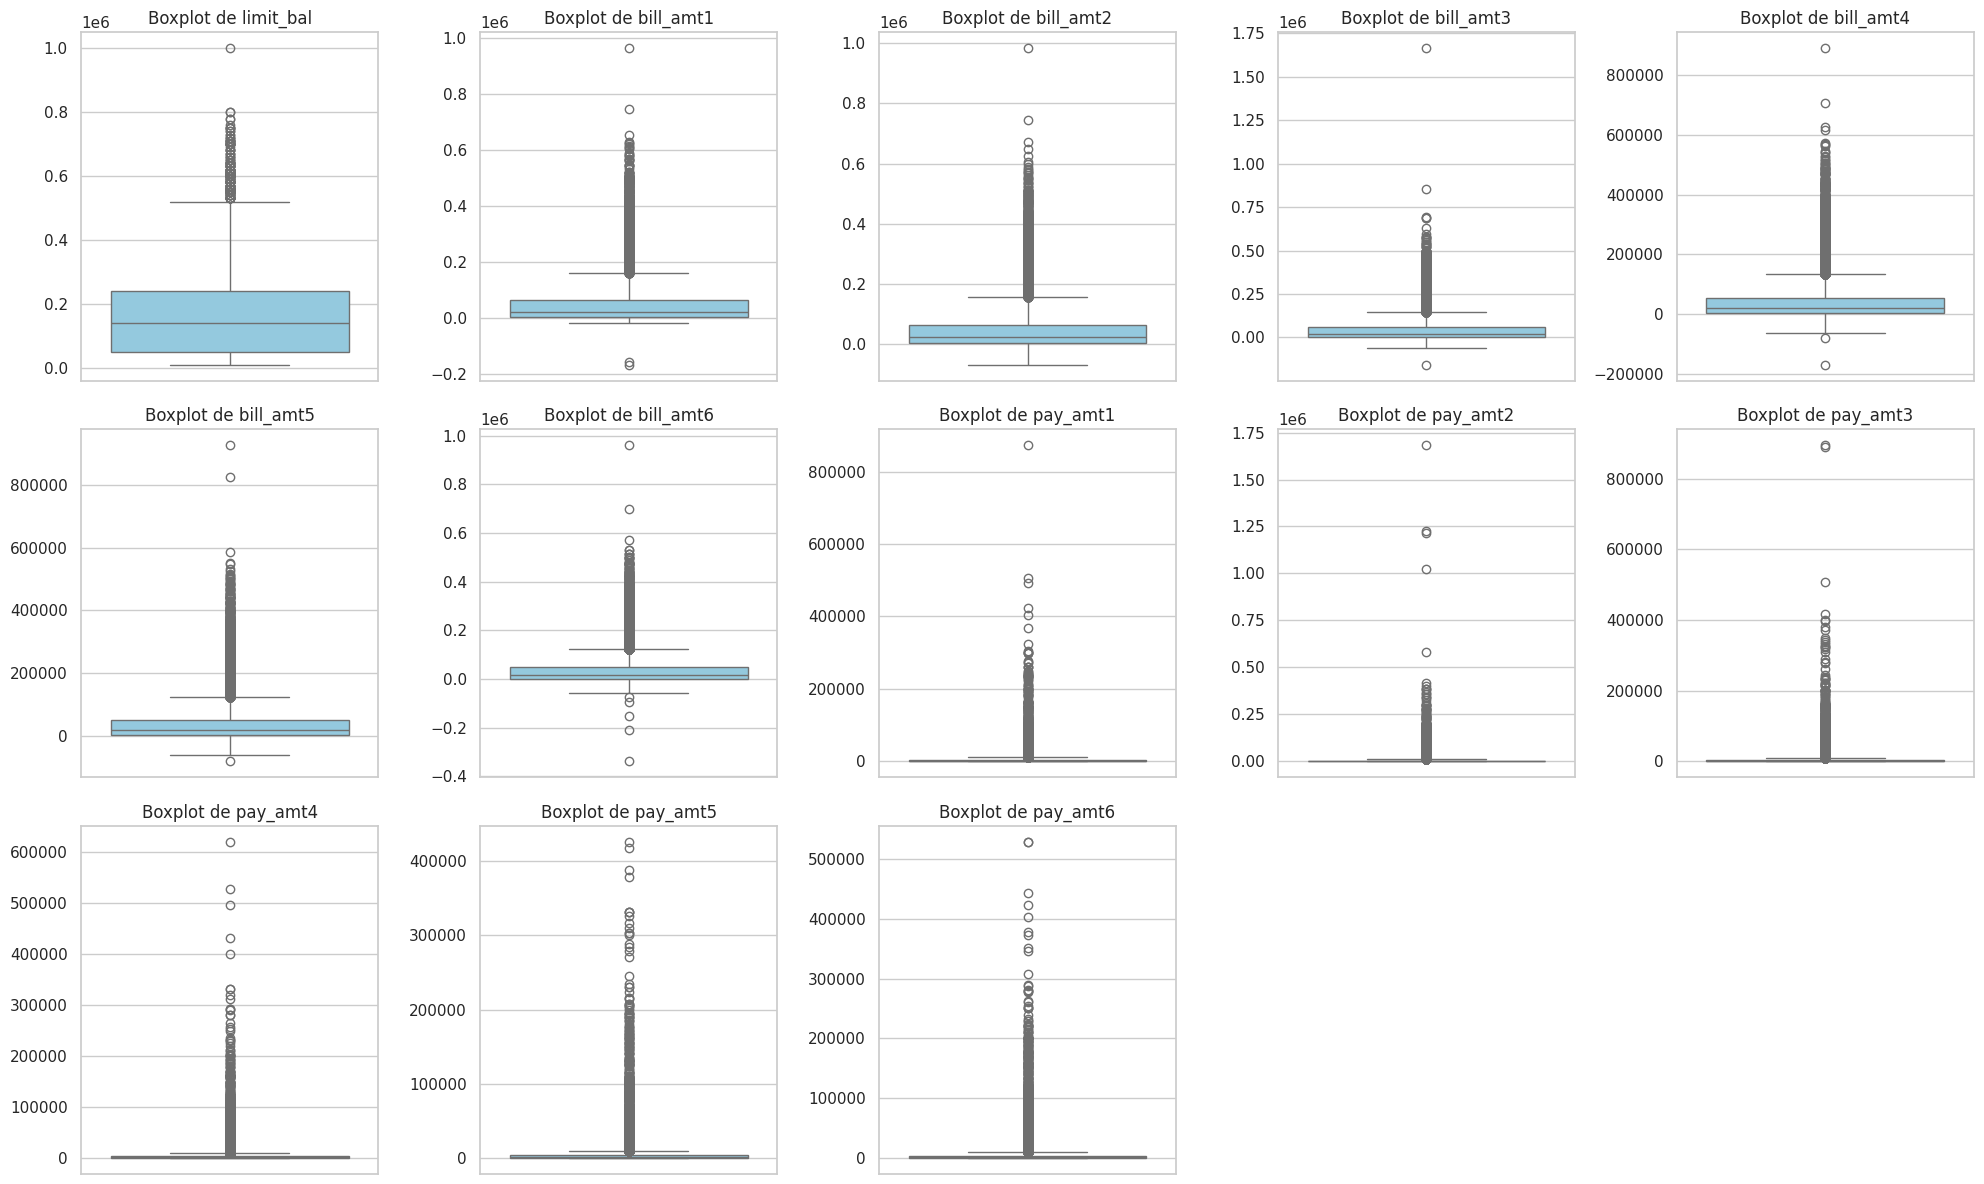

In [ ]:
# 8. Revisión de outliers

print("--- Visualización de Outliers con Box Plots ---")

# Configuramos un estilo limpio para los gráficos
sns.set_theme(style="whitegrid")

# Definimos las columnas continuas a evaluar. 
# Excluimos variables categóricas, target y los estados de pago (pay_0 a pay_6) porque sus valores (-2 a 8) son categorías.
money_cols = ['limit_bal'] + [col for col in df.columns if col.startswith('bill_amt')] + [col for col in df.columns if col.startswith('pay_amt')]

# Creamos una figura grande con subplots (grid de 3 filas x 5 columnas)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12))
axes = axes.flatten() # Aplanamos el array de ejes para iterar fácilmente

for i, col in enumerate(money_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f"Boxplot de {col}", fontsize=12)
    axes[i].set_ylabel('') # Ocultamos el label del eje Y para limpieza visual

# Ocultamos los subplots sobrantes (tenemos 15 espacios pero solo 13 variables)
for j in range(len(money_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
# 9. Detección Numérica y Tratamiento de Outliers (Winsorization)

# 9.1. Definimos las columnas continuas a evaluar. 
# Excluimos variables categóricas, target y los estados de pago (pay_0 a pay_6) porque sus valores (-2 a 8) son categorías.
cols_continuas = ['limit_bal', 'age'] + [col for col in df.columns if col.startswith('bill_amt')] + [col for col in df.columns if col.startswith('pay_amt')]

columnas_con_outliers = []
print("--- Detección Numérica de Outliers (Método IQR) ---")

# 9.2. Detección programática
for col in cols_continuas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contamos cuántos valores exceden los límites matemáticos
    outliers_count = ((df[col] < limite_inferior) | (df[col] > limite_superior)).sum()
    
    if outliers_count > 0:
        columnas_con_outliers.append(col)
        print(f"{col}: {outliers_count} outliers detectados.")

print(f"\nLista de columnas a tratar ({len(columnas_con_outliers)} en total):")
print(columnas_con_outliers)

--- Detección Numérica de Outliers (Método IQR) ---
limit_bal: 167 outliers detectados.
age: 272 outliers detectados.
bill_amt1: 2400 outliers detectados.
bill_amt2: 2395 outliers detectados.
bill_amt3: 2469 outliers detectados.
bill_amt4: 2622 outliers detectados.
bill_amt5: 2725 outliers detectados.
bill_amt6: 2693 outliers detectados.
pay_amt1: 2745 outliers detectados.
pay_amt2: 2714 outliers detectados.
pay_amt3: 2598 outliers detectados.
pay_amt4: 2994 outliers detectados.
pay_amt5: 2945 outliers detectados.
pay_amt6: 2958 outliers detectados.

Lista de columnas a tratar (14 en total):
['limit_bal', 'age', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']


In [17]:
# 9.3. Tratamiento (Winsorization al 1% y 99%) SOLO sobre nuestra lista validada
percentil_inferior = 0.01
percentil_superior = 0.99

for col in columnas_con_outliers:
    q_low = df[col].quantile(percentil_inferior)
    q_hi  = df[col].quantile(percentil_superior)
    df[col] = df[col].clip(lower=q_low, upper=q_hi)

print("\n--- Tratamiento Winsorization aplicado con éxito a la lista ---")


--- Tratamiento Winsorization aplicado con éxito a la lista ---


### Plot distributions

Plotear distribuciones, en concreto, la distribución de nuestra variable estrella: la Variable Objetivo (default_payment).

- Distribución de la Variable Objetivo (El problema del Desbalanceo)
- Enfoque de Negocio:
-- En la banca, la inmensa mayoría de los clientes pagan sus tarjetas a tiempo. Los morosos son una minoría. Si resulta que el 80% de nuestros clientes en el dataset son "buenos" y el 20% son "malos", tenemos un Dataset Desbalanceado.

¿Por qué nos importa ahora? Porque si no lo sabemos, en la etapa de modelado y evaluación podríamos entrenar un modelo mediocre que diga "Ningún cliente va a impagar nunca", y ese modelo tendría un 80% de Accuracy (Exactitud).

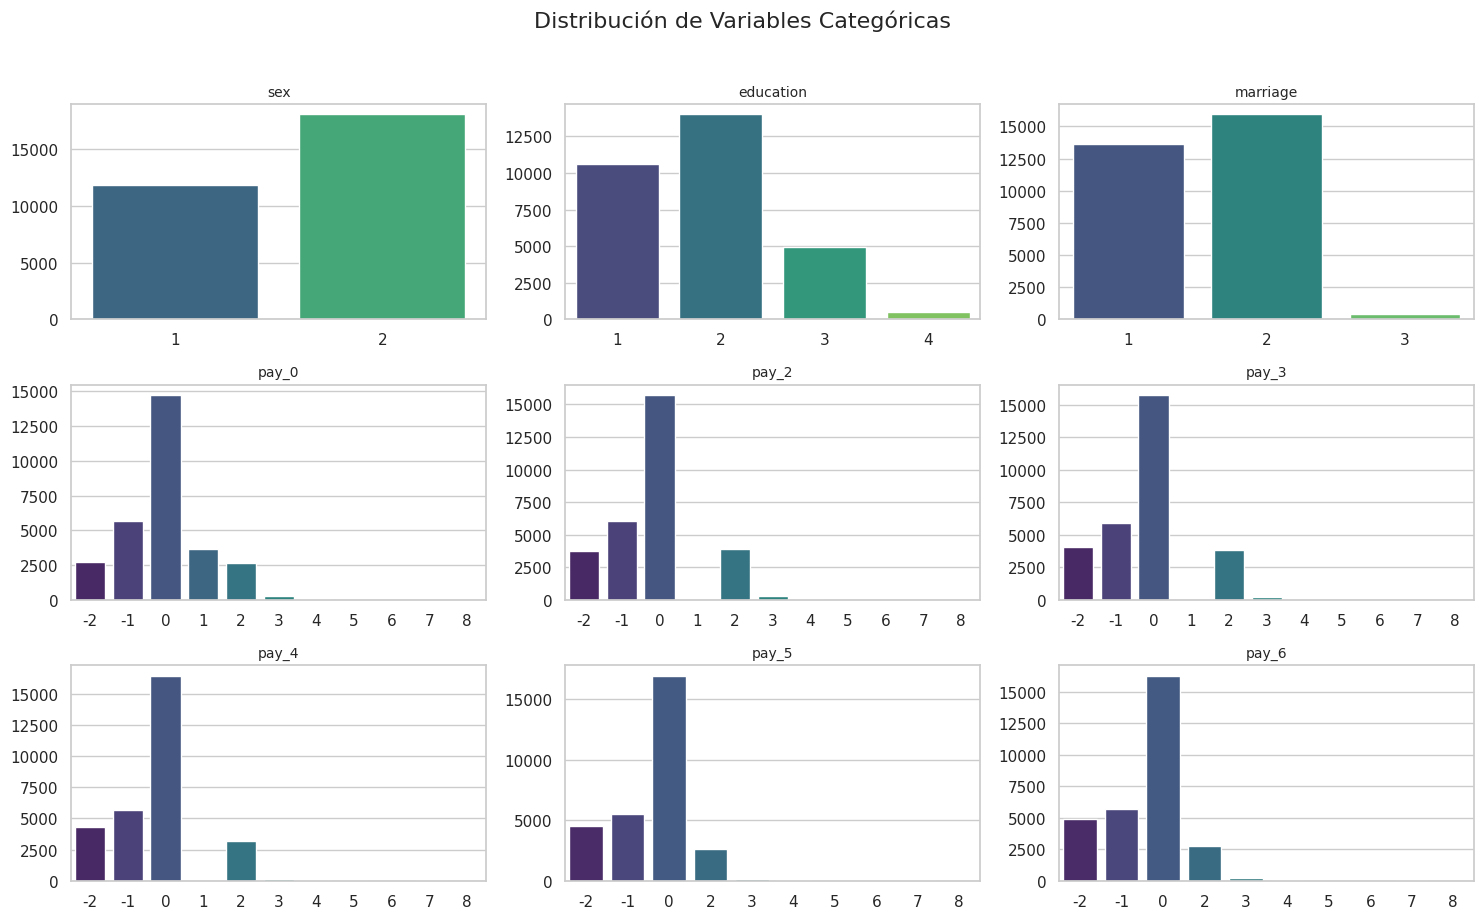

In [20]:
# 10. PLOT DISTRIBUTIONS

# ==========================================
# 1. DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS
# ==========================================
# Incluimos sexo, educación, matrimonio y los historiales de estado de pago (pay_0 a pay_6)
cat_cols = ['sex', 'education', 'marriage'] + [col for col in df.columns if col.startswith('pay_') and len(col) == 5]

# Calculamos el tamaño de la cuadrícula (ej. 3x3 o 4x3)
n_cat = len(cat_cols)
cols_grid = 3
rows_grid = math.ceil(n_cat / cols_grid)

fig, axes = plt.subplots(nrows=rows_grid, ncols=cols_grid, figsize=(15, 3 * rows_grid))
fig.suptitle('Distribución de Variables Categóricas', fontsize=16, y=1.02)
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

# Ocultar subplots vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

1. **Variables Categóricas:**
   * La mayor parte de la cartera de clientes de este dataset son mujeres (`sex=2`), con educación universitaria o de posgrado (`education` 1 y 2), y el estado civil está bastante equilibrado entre casados y solteros.
   * En el historial de pagos (`pay_0` a `pay_6`), la abrumadora mayoría de los clientes están en estado `0` (pago mínimo/crédito revolving) o `-1` (pago total a tiempo), y un porcentaje restante con `-2` que son los que no tienen consumo. Los retrasos severos (2 o más meses) son una minoría clara.

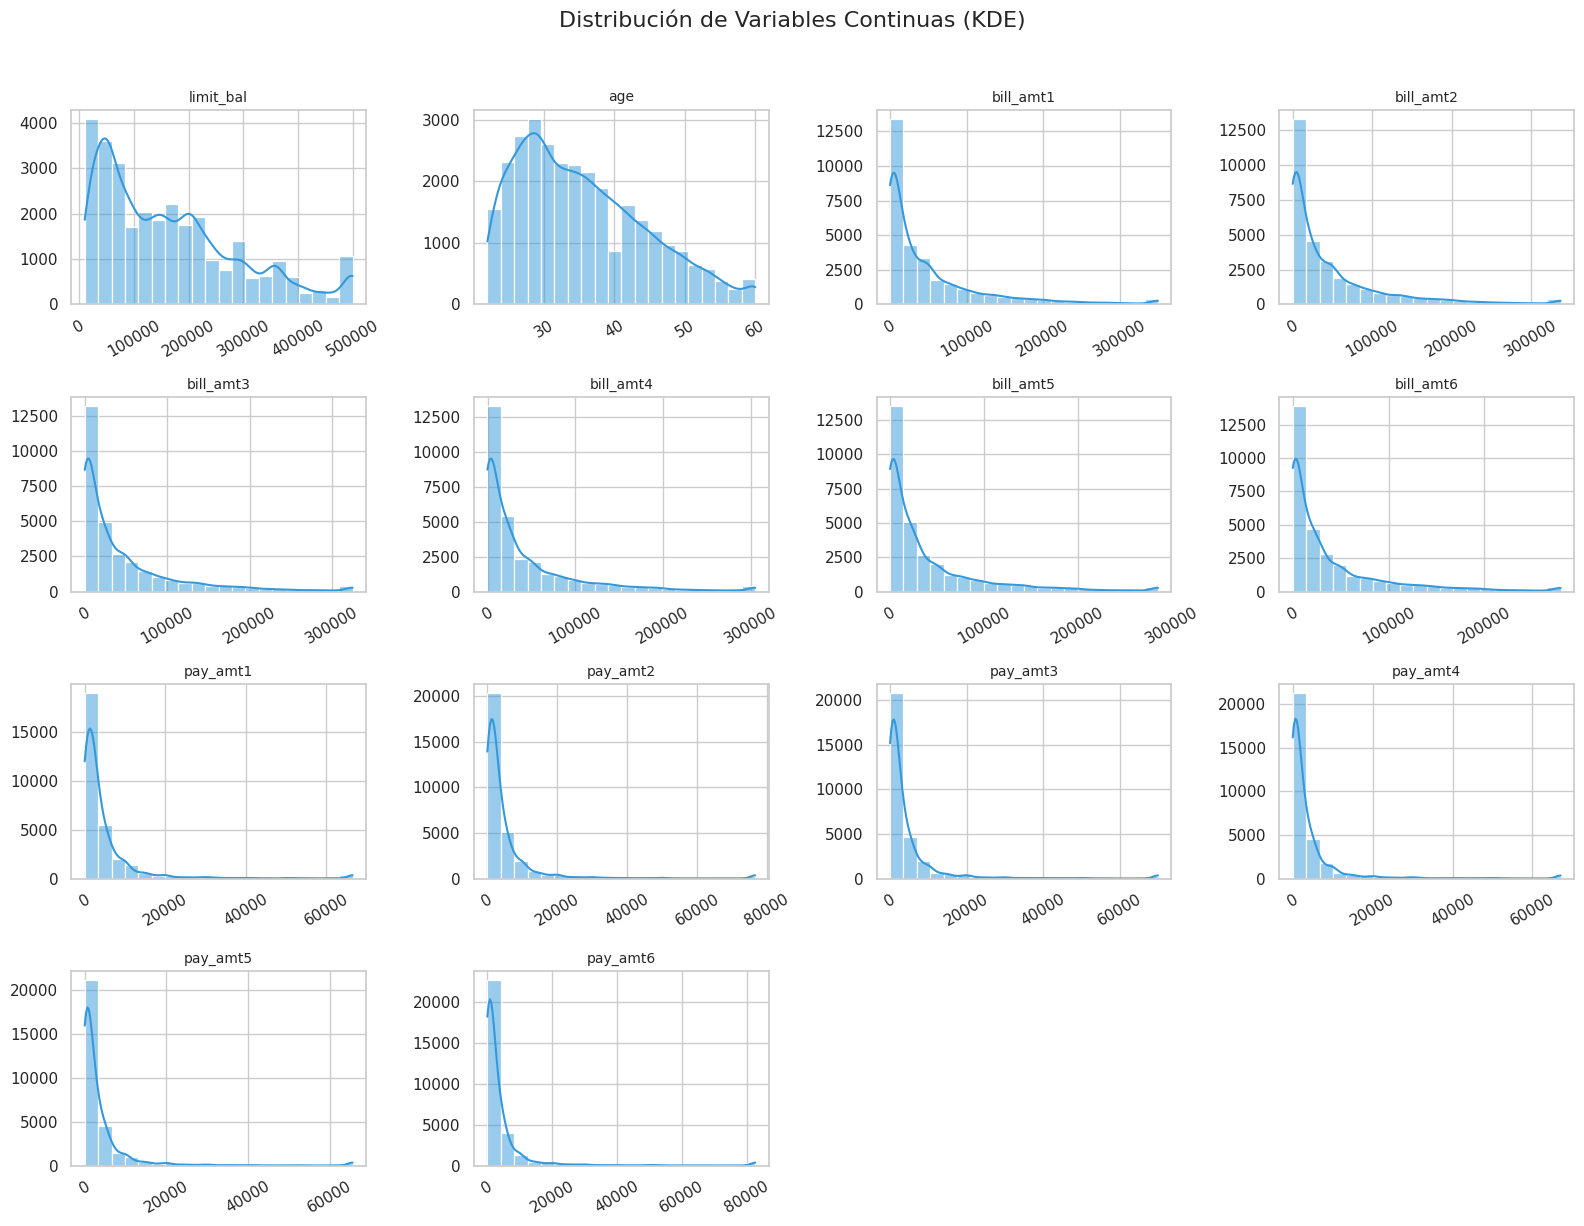

In [21]:
# ==========================================
# 2. DISTRIBUCIÓN DE VARIABLES CONTINUAS
# ==========================================
# Incluimos limit_bal, age, y los montos de facturación y pago
cont_cols = ['limit_bal', 'age'] + [col for col in df.columns if col.startswith('bill_amt')] + [col for col in df.columns if col.startswith('pay_amt')]

n_cont = len(cont_cols)
rows_grid_cont = math.ceil(n_cont / 4) # 4 columnas por fila para que quepan bien

fig, axes = plt.subplots(nrows=rows_grid_cont, ncols=4, figsize=(16, 3 * rows_grid_cont))
fig.suptitle('Distribución de Variables Continuas (KDE)', fontsize=16, y=1.02)
axes = axes.flatten()

for i, col in enumerate(cont_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#3498db', bins=20)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')
    # Rotar las etiquetas del eje X porque los montos monetarios son largos
    axes[i].tick_params(axis='x', rotation=30) 

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

2. **Variables Continuas (Asimetría):**
   * A pesar de haber aplicado *Winsorization* para contener los outliers extremos, variables como los límites de crédito (`limit_bal`), facturaciones (`bill_amt`) y pagos (`pay_amt`) presentan una **fuerte asimetría positiva** (están sesgadas hacia la izquierda).
   * *Impacto técnico:* No tienen una distribución normal (campana de Gauss). Para que algoritmos basados en distancias (como la Regresión Logística) funcionen correctamente y no se sesguen, será obligatorio aplicar una estandarización o normalización en la siguiente fase.


--- Distribución de la Variable Objetivo (Target) ---


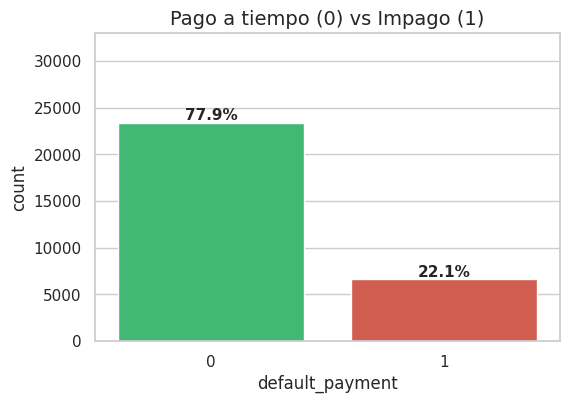

In [22]:
# ==========================================
# 3. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ==========================================
print("\n--- Distribución de la Variable Objetivo (Target) ---")

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='default_payment', palette=['#2ecc71', '#e74c3c'])
plt.title('Pago a tiempo (0) vs Impago (1)', fontsize=14)

# Añadimos los porcentajes a las barras
for p in ax.patches:
    altura = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., altura + 300,
            f'{altura/len(df)*100:.1f}%', 
            ha="center", fontsize=11, fontweight='bold')

plt.ylim(0, len(df)*1.1)
plt.show()

3. **Variable Objetivo (Desbalanceo):**
   * El dataset presenta un claro desbalanceo: aproximadamente el **77.9%** de los clientes son buenos pagadores (0) frente a un **22.1%** de clientes que incurren en impago (1).
   * *Impacto en negocio:* Un modelo inútil que prediga que "nadie impaga" tendría un ~78% de exactitud (*Accuracy*). Por tanto, descartaremos el *Accuracy* como métrica principal y nos enfocaremos en métricas como el **Recall** o el **F1-Score** para asegurar que el banco detecta correctamente los Falsos Negativos (riesgo real de impago).